# CICIDS-2017 Network Intrusion Detection — Model Comparison Pipeline
**Vikash Sharma | 270655771 | MBI908 Capstone**

Classifiers: Logistic Regression, Decision Tree, Random Forest
Conditions: Imbalanced (raw quota sample) vs SMOTE-balanced
Dataset: CICIDS-2017 (cleaned/preprocessed version), 7 traffic classes

**Fixes applied in this version:**
1. Added `StandardScaler` (fit on train, applied to test) — was missing, and is specified in
   the Assessment 1 methodology. This matters most for Logistic Regression, which is scale-sensitive.
2. Step 12's chart now reads from the actual computed `results` DataFrame instead of hardcoded numbers.
3. Sampling is clearly documented as **disproportionate stratified sampling with fixed per-class quotas**
   (not simple proportional stratified sampling) — see the note in Step 5 for why.


In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ── Set these two paths for your machine ──────────────────────────────
DATA_PATH = r"C:\Users\vikas\Documents\cicids2017_cleaned.csv"
OUTPUT_DIR = r"C:\Users\vikas\Documents"
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [2]:
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
# Step 2: Load the Dataset
df = pd.read_csv(DATA_PATH)

# Step 3: Basic Exploration
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (2520751, 53)


,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,...,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,...,290,0,32,0.0,0,0,0.0,0,0,Normal Traffic


In [22]:
# Step 4: Check column names and target variable distribution
print("Column Names:")
print(df.columns.tolist())

print("\nTarget Variable Distribution ('Attack Type'):")
print(df['Attack Type'].value_counts())


Column Names:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Active Max', 'Active Min', 'Idle Mean', '

### Step 5 — Sampling note
The full dataset is heavily imbalanced (Normal Traffic ≈ 83%, down to Bots/Web Attacks at ~0.08% each).
A **true proportional** stratified sample of 20,000 rows would only contain ~15–17 rows each for
Bots and Web Attacks — far too few to train or evaluate on reliably.

Instead we use **fixed per-class quotas** below. This is a deliberate, documented deviation from strict
proportional stratified sampling, and should be described as such in the Methodology section
(rather than "preserves the original class proportions").


In [23]:
# Step 5: Disproportionate stratified sample using fixed per-class quotas
sample_sizes = {
    'Normal Traffic': 10000,
    'DoS': 3000,
    'DDoS': 2500,
    'Port Scanning': 2000,
    'Brute Force': 1000,
    'Web Attacks': 750,
    'Bots': 750
}

df_sample = pd.concat([
    df[df['Attack Type'] == attack_type].sample(n=n, random_state=42)
    for attack_type, n in sample_sizes.items()
])

df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

print("Sample shape:", df_sample.shape)
print("\nSample Distribution:")
print(df_sample['Attack Type'].value_counts())


Sample shape: (20000, 53)

Sample Distribution:
Attack Type
Normal Traffic    10000
DoS                3000
DDoS               2500
Port Scanning      2000
Brute Force        1000
Bots                750
Web Attacks         750
Name: count, dtype: int64


In [25]:
# Step 6: Check for missing/infinite values and clean
print("Missing Values:", df_sample.isnull().sum().sum())

df_sample = df_sample.replace([np.inf, -np.inf], np.nan).dropna()

print("Cleaned Sample Shape:", df_sample.shape)


Missing Values: 0
Cleaned Sample Shape: (20000, 53)


In [7]:
# Step 7: Prepare features and target variable
from sklearn.preprocessing import LabelEncoder

X = df_sample.drop('Attack Type', axis=1)
y = df_sample['Attack Type']

le = LabelEncoder()
y = le.fit_transform(y)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nAttack Type Labels:")
for i, label in enumerate(le.classes_):
    print(f"  {i} = {label}")


Features shape: (20000, 52)
Target shape: (20000,)

Attack Type Labels:
  0 = Bots
  1 = Brute Force
  2 = DDoS
  3 = DoS
  4 = Normal Traffic
  5 = Port Scanning
  6 = Web Attacks


In [8]:
# Step 8: Split data into training and testing sets (80/20, stratified)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (16000, 52)
Testing set size: (4000, 52)


In [9]:
# Step 9: Feature scaling (StandardScaler) — fit on TRAIN ONLY, applied to test
# This was missing from the original notebook. Logistic Regression in particular is
# sensitive to feature scale (e.g. Flow Duration in the millions vs 0/1 flag columns).
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Scaling complete. Example — before vs after (Flow Duration):")
print("Before:", X_train['Flow Duration'].iloc[0], " | After:", X_train_scaled['Flow Duration'].iloc[0])


Scaling complete. Example — before vs after (Flow Duration):
Before: 4279591  | After: -0.41588214120908396


In [10]:
# Step 10a: Train and Evaluate All Three Models WITHOUT SMOTE (Imbalanced Condition)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def make_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
    }

print("=" * 60)
print("IMBALANCED CONDITION — Training WITHOUT SMOTE")
print("=" * 60)

models_imb = make_models()
results_imbalanced = []
per_class_imbalanced = {}

for model_name, model in models_imb.items():
    print(f"\nTraining {model_name} (Imbalanced)...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results_imbalanced.append({
        "Model": model_name, "Condition": "Imbalanced",
        "Accuracy": round(accuracy * 100, 2),
        "Precision": round(precision * 100, 2),
        "Recall": round(recall * 100, 2),
        "F1-Score": round(f1 * 100, 2)
    })

    report_dict = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
    per_class_imbalanced[model_name] = {
        "Bots Recall": round(report_dict["Bots"]["recall"] * 100, 2),
        "Web Attacks Recall": round(report_dict["Web Attacks"]["recall"] * 100, 2),
        "Bots F1": round(report_dict["Bots"]["f1-score"] * 100, 2),
        "Web Attacks F1": round(report_dict["Web Attacks"]["f1-score"] * 100, 2)
    }

    print(f"Accuracy: {accuracy*100:.2f}%  Precision: {precision*100:.2f}%  Recall: {recall*100:.2f}%  F1: {f1*100:.2f}%")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

print("\nAll three models (Imbalanced condition) completed!")


IMBALANCED CONDITION — Training WITHOUT SMOTE

Training Logistic Regression (Imbalanced)...
Accuracy: 92.62%  Precision: 93.27%  Recall: 92.62%  F1: 92.32%
                precision    recall  f1-score   support

          Bots       0.98      0.41      0.58       150
   Brute Force       0.76      0.97      0.85       200
          DDoS       0.93      1.00      0.96       500
           DoS       0.97      0.93      0.95       600
Normal Traffic       0.96      0.93      0.94      2000
 Port Scanning       0.83      0.99      0.90       400
   Web Attacks       0.92      0.87      0.89       150

      accuracy                           0.93      4000
     macro avg       0.91      0.87      0.87      4000
  weighted avg       0.93      0.93      0.92      4000


Training Decision Tree (Imbalanced)...
Accuracy: 99.30%  Precision: 99.30%  Recall: 99.30%  F1: 99.30%
                precision    recall  f1-score   support

          Bots       0.96      0.96      0.96       150
   Brute

In [11]:
# Step 10b: Apply SMOTE to the SCALED training data only
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE - Training size:", X_train_scaled.shape)
print("After SMOTE - Training size:", X_train_smote.shape)
print("\nAfter SMOTE Distribution:")
unique, counts = np.unique(y_train_smote, return_counts=True)
for label, count in zip(le.classes_, counts):
    print(f"  {label}: {count}")


Before SMOTE - Training size: (16000, 52)
After SMOTE - Training size: (56000, 52)

After SMOTE Distribution:
  Bots: 8000
  Brute Force: 8000
  DDoS: 8000
  DoS: 8000
  Normal Traffic: 8000
  Port Scanning: 8000
  Web Attacks: 8000


In [12]:
# Step 11: Train and Evaluate All Three Models on SMOTE-balanced data
models = make_models()
results = []
preds_store = {}

for model_name, model in models.items():
    print(f"\nTraining {model_name} (SMOTE)...")
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test_scaled)
    preds_store[model_name] = y_pred

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results.append({
        "Model": model_name, "Condition": "SMOTE",
        "Accuracy": round(accuracy * 100, 2),
        "Precision": round(precision * 100, 2),
        "Recall": round(recall * 100, 2),
        "F1-Score": round(f1 * 100, 2)
    })

    print(f"Accuracy: {accuracy*100:.2f}%  Precision: {precision*100:.2f}%  Recall: {recall*100:.2f}%  F1: {f1*100:.2f}%")

print("\nAll three models (SMOTE condition) completed!")



Training Logistic Regression (SMOTE)...
Accuracy: 90.67%  Precision: 93.10%  Recall: 90.67%  F1: 91.11%

Training Decision Tree (SMOTE)...
Accuracy: 99.15%  Precision: 99.16%  Recall: 99.15%  F1: 99.15%

Training Random Forest (SMOTE)...
Accuracy: 99.52%  Precision: 99.53%  Recall: 99.52%  F1: 99.53%

All three models (SMOTE condition) completed!


In [13]:
# Step 12: Combine and save Imbalanced vs SMOTE comparison
comparison_df = pd.DataFrame(results_imbalanced + results)
comparison_df = comparison_df[["Model", "Condition", "Accuracy", "Precision", "Recall", "F1-Score"]]
comparison_df = comparison_df.sort_values(by=["Model", "Condition"]).reset_index(drop=True)

print("=" * 80)
print("OVERALL COMPARISON: Imbalanced vs SMOTE-Balanced (Weighted Averages)")
print("=" * 80)
print(comparison_df.to_string(index=False))

comparison_df.to_csv(os.path.join(OUTPUT_DIR, "comparison_imbalanced_vs_smote.csv"), index=False)
print("\nSaved: comparison_imbalanced_vs_smote.csv")


OVERALL COMPARISON: Imbalanced vs SMOTE-Balanced (Weighted Averages)
              Model  Condition  Accuracy  Precision  Recall  F1-Score
      Decision Tree Imbalanced     99.30      99.30   99.30     99.30
      Decision Tree      SMOTE     99.15      99.16   99.15     99.15
Logistic Regression Imbalanced     92.62      93.27   92.62     92.32
Logistic Regression      SMOTE     90.67      93.10   90.67     91.11
      Random Forest Imbalanced     99.55      99.55   99.55     99.55
      Random Forest      SMOTE     99.52      99.53   99.52     99.53

Saved: comparison_imbalanced_vs_smote.csv


In [14]:
# Step 13: Minority-class detail (Bots and Web Attacks) — Imbalanced vs SMOTE
per_class_rows = []
for model_name in ["Logistic Regression", "Decision Tree", "Random Forest"]:
    imb = per_class_imbalanced.get(model_name, {})
    per_class_rows.append({
        "Model": model_name, "Condition": "Imbalanced",
        "Bots Recall": imb.get("Bots Recall", "N/A"),
        "Bots F1": imb.get("Bots F1", "N/A"),
        "Web Atk Recall": imb.get("Web Attacks Recall", "N/A"),
        "Web Atk F1": imb.get("Web Attacks F1", "N/A")
    })

for model_name, y_pred_s in preds_store.items():
    rep = classification_report(y_test, y_pred_s, target_names=le.classes_, output_dict=True)
    per_class_rows.append({
        "Model": model_name, "Condition": "SMOTE",
        "Bots Recall": round(rep["Bots"]["recall"] * 100, 2),
        "Bots F1": round(rep["Bots"]["f1-score"] * 100, 2),
        "Web Atk Recall": round(rep["Web Attacks"]["recall"] * 100, 2),
        "Web Atk F1": round(rep["Web Attacks"]["f1-score"] * 100, 2)
    })

minority_df = pd.DataFrame(per_class_rows).sort_values(by=["Model", "Condition"]).reset_index(drop=True)
print(minority_df.to_string(index=False))

minority_df.to_csv(os.path.join(OUTPUT_DIR, "minority_class_comparison.csv"), index=False)
print("\nSaved: minority_class_comparison.csv")
print("\nFor RQ2: compare Bots/Web Attacks Recall between Imbalanced and SMOTE rows above.")


              Model  Condition  Bots Recall  Bots F1  Web Atk Recall  Web Atk F1
      Decision Tree Imbalanced        96.00    96.00          100.00       99.67
      Decision Tree      SMOTE        99.33    98.35           98.67       96.10
Logistic Regression Imbalanced        40.67    57.55           87.33       89.42
Logistic Regression      SMOTE       100.00    69.77           92.67       89.39
      Random Forest Imbalanced        98.67    98.67           98.00       98.99
      Random Forest      SMOTE       100.00    97.72           98.67       99.33

Saved: minority_class_comparison.csv

For RQ2: compare Bots/Web Attacks Recall between Imbalanced and SMOTE rows above.


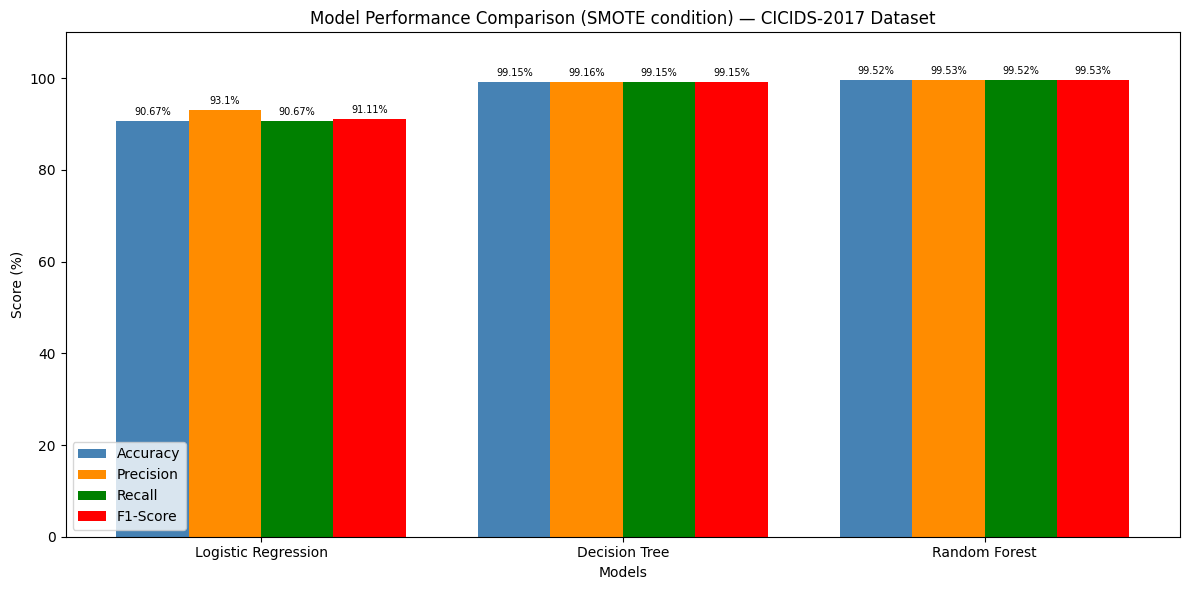

Chart saved.


In [15]:
# Step 14: Visualise Results — now reads from the ACTUAL computed results (not hardcoded)
# Uses the SMOTE-condition results, since that's the final recommended model comparison
plot_df = comparison_df[comparison_df["Condition"] == "SMOTE"].set_index("Model")
plot_df = plot_df.loc[["Logistic Regression", "Decision Tree", "Random Forest"]]

models_names = plot_df.index.tolist()
accuracy = plot_df["Accuracy"].tolist()
precision = plot_df["Precision"].tolist()
recall = plot_df["Recall"].tolist()
f1 = plot_df["F1-Score"].tolist()

x = np.arange(len(models_names))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - 1.5*width, accuracy, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x - 0.5*width, precision, width, label='Precision', color='darkorange')
bars3 = ax.bar(x + 0.5*width, recall, width, label='Recall', color='green')
bars4 = ax.bar(x + 1.5*width, f1, width, label='F1-Score', color='red')

ax.set_xlabel('Models')
ax.set_ylabel('Score (%)')
ax.set_title('Model Performance Comparison (SMOTE condition) — CICIDS-2017 Dataset')
ax.set_xticks(x)
ax.set_xticklabels(models_names)
ax.legend()
ax.set_ylim(0, 110)

for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "model_comparison.png"), dpi=150)
plt.show()
print("Chart saved.")


In [16]:
# Step 15: Detailed per-class classification report for the best model (Random Forest, SMOTE-trained)
rf_model = models['Random Forest']
y_pred_rf = preds_store['Random Forest']

print("=" * 60)
print("RANDOM FOREST - Detailed Results Per Attack Type")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

report_df = pd.DataFrame(
    classification_report(y_test, y_pred_rf, target_names=le.classes_, output_dict=True)
).transpose()

# Convert precision/recall/f1 to percentage for readability (leave 'support' as row counts)
for col in ['precision', 'recall', 'f1-score']:
    report_df[col] = (report_df[col] * 100).round(2)

report_df.to_csv(os.path.join(OUTPUT_DIR, "rf_detailed_results.csv"))
print(report_df)
print("\nSaved: rf_detailed_results.csv")


RANDOM FOREST - Detailed Results Per Attack Type
                precision    recall  f1-score   support

          Bots       0.96      1.00      0.98       150
   Brute Force       1.00      0.99      1.00       200
          DDoS       1.00      1.00      1.00       500
           DoS       0.99      0.99      0.99       600
Normal Traffic       1.00      0.99      1.00      2000
 Port Scanning       0.99      1.00      1.00       400
   Web Attacks       1.00      0.99      0.99       150

      accuracy                           1.00      4000
     macro avg       0.99      1.00      0.99      4000
  weighted avg       1.00      1.00      1.00      4000

                precision  recall  f1-score     support
Bots                95.54  100.00     97.72   150.00000
Brute Force        100.00   99.50     99.75   200.00000
DDoS               100.00   99.80     99.90   500.00000
DoS                 99.33   99.50     99.42   600.00000
Normal Traffic      99.80   99.40     99.60  2000.00